# LambdaRank on LETOR4
### Learning to Rank — Pairwise Neural Approach
---
**Dataset**: LETOR4 (MQ2008)  
**Model**: LambdaRank — Deep Pointwise Scoring Network  
**Gradients**: Lambda(λ)  
**Metrics**: NDCG@K

## Project Overview

This notebook implements **RankNet**, one of the foundational Learning-to-Rank (LTR) algorithms in Information Retrieval. The goal is to train a neural network that can order a list of documents by relevance for a given search query

### What this notebook covers
| Step | Description |
|------|-------------|
| 1–2  | Environment setup and dataset acquisition (LETOR4 / MQ2008) |
| 3    | Query-grouped PyTorch Dataset and DataLoader |
| 4–5  | Model architecture and gradient computing functions |
| 6–8 | Training and dropout regularization |
| 9   | Test-set NDCG evaluation |
| 10   | 5-Fold Cross-Validation for statistical reliability |
| 11   | Ablation study across 4 architectures |

## Step 1 · Environment, Repository Structure & Dependency Setup
Install all required libraries, fix the random seed and verify GPU

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"NumPy version   : {np.__version__}")
print(f"Pandas version  : {pd.__version__}")

PyTorch version : 2.11.0+cu128
NumPy version   : 2.0.2
Pandas version  : 2.2.2


## Step 2 · Raw Dataset Acquisition & libsvm Format Inspection
Extract the LETOR4 zip and inspect the file structure.

In [2]:
import zipfile, os

zip_name = "MQ2008.zip"
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/content/")

print("\nExtraction complete. Contents:")


Extraction complete. Contents:


In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Inspecting the Raw Data Format (`libsvm`)
The LETOR dataset uses the standard `libsvm` format, where each row represents a single document evaluated for a specific search query.

In [3]:
sample_file = "/content/MQ2008/Fold1/train.txt"
print(f"Inspecting: {sample_file}\n")
print("─" * 80)

with open(sample_file, "r") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i == 4:
            break

print("─" * 80)
print("""
libsvm format breakdown:
  <relevance>  qid:<query_id>  1:<f1>  2:<f2>  ...  46:<f46>  #docid=...

  relevance → integer label  (0 = not relevant, 1 = relevant, 2 = highly relevant)
  qid       → query group id (all docs sharing a qid form one ranking list)
  1..46     → 46 pre-computed IR features (TF, IDF, BM25, PageRank, etc.)
  #docid    → trailing comment with document id (ignored during parsing)
""")

Inspecting: /content/MQ2008/Fold1/train.txt

────────────────────────────────────────────────────────────────────────────────
0 qid:10002 1:0.007477 2:0.000000 3:1.000000 4:0.000000 5:0.007470 6:0.000000 7:0.000000 8:0.000000 9:0.000000 10:0.000000 11:0.471076 12:0.000000 13:1.000000 14:0.000000 15:0.477541 16:0.005120 17:0.000000 18:0.571429 19:0.000000 20:0.004806 21:0.768561 22:0.727734 23:0.716277 24:0.582061 25:0.000000 26:0.000000 27:0.000000 28:0.000000 29:0.780495 30:0.962382 31:0.999274 32:0.961524 33:0.000000 34:0.000000 35:0.000000 36:0.000000 37:0.797056 38:0.697327 39:0.721953 40:0.582568 41:0.000000 42:0.000000 43:0.000000 44:0.000000 45:0.000000 46:0.007042 #docid = GX008-86-4444840 inc = 1 prob = 0.086622
0 qid:10002 1:0.603738 2:0.000000 3:1.000000 4:0.000000 5:0.603175 6:0.000000 7:0.000000 8:0.000000 9:0.000000 10:0.000000 11:0.000000 12:0.000000 13:0.122130 14:0.000000 15:0.000000 16:0.998377 17:0.375000 18:1.000000 19:0.000000 20:0.998128 21:0.000000 22:0.000000 23

## Step 3 · Query-Grouped Data Loading
RankNet evaluates pairs of documents for the exact same search query. Therefore, our PyTorch `Dataset` must yield data strictly grouped by `qid`. Since different queries have a different number of candidate documents, we will use a custom `collate_fn` to handle variable-length batches.

In [4]:
class LETORQueryDataset(Dataset):
    """
    Parses a LETOR libsvm file and groups documents by Query ID.
    Returns: (qid, features_tensor, labels_tensor) for a single query.
    """
    def __init__(self, filepath):
        self.filepath = filepath
        self.queries = [] # Will hold tuples of (qid, features, labels)
        self._load_and()

    def _load_and(self):
        current_qid = None
        current_features = []
        current_labels = []

        with open(self.filepath, 'r') as f:
            for line in tqdm(f, desc=f"Loading {os.path.basename(self.filepath)}"):
                parts = line.strip().split()
                if not parts:
                    continue

                label = int(parts[0])
                qid = parts[1].split(':')[1]
                features = [float(x.split(':')[1]) for x in parts[2:48]]

                # If we hit a new query, save the old one and start fresh
                if current_qid is not None and qid != current_qid:
                    # Only keep queries with >1 document (needed for pairwise comparison)
                    if len(current_labels) > 1:
                        self.queries.append((
                            current_qid,
                            torch.tensor(current_features, dtype=torch.float32),
                            torch.tensor(current_labels, dtype=torch.float32)
                        ))
                    current_features = []
                    current_labels = []

                current_qid = qid
                current_features.append(features)
                current_labels.append(label)

            # Don't forget to save the very last query in the file
            if current_qid is not None and len(current_labels) > 1:
                self.queries.append((
                    current_qid,
                    torch.tensor(current_features, dtype=torch.float32),
                    torch.tensor(current_labels, dtype=torch.float32)
                ))

    def __len__(self):
        return len(self.queries)

    def __getitem__(self, idx):
        return self.queries[idx]

def query_collate_fn(batch):
    """
    Handles batching of queries with varying numbers of documents.
    Returns lists of tensors instead of stacking them into a single rigid tensor.
    """
    qids = [item[0] for item in batch]
    features = [item[1] for item in batch]
    labels = [item[2] for item in batch]
    return qids, features, labels

### Generalized DataLoader Function
To prepare for 5-Fold Cross-Validation, we will wrap our dataset initialization into a dynamic function. This allows us to pass a fold number (1-5) and instantly get the correct Train, Validation, and Test loaders back.

In [5]:
def get_dataloaders_for_fold(base_path="/content/MQ2008", fold_num=1, batch_size=4):
    """
    Dynamically loads the Train, Validation, and Test DataLoaders for a specific fold.
    """
    print(f"\nInitializing DataLoaders for Fold {fold_num}...")
    fold_dir = os.path.join(base_path, f"Fold{fold_num}")

    train_path = os.path.join(fold_dir, "train.txt")
    vali_path  = os.path.join(fold_dir, "vali.txt")
    test_path  = os.path.join(fold_dir, "test.txt")

    # Instantiate Datasets
    train_dataset = LETORQueryDataset(train_path)
    vali_dataset  = LETORQueryDataset(vali_path)
    test_dataset  = LETORQueryDataset(test_path)

    # Instantiate DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=query_collate_fn)
    vali_loader  = DataLoader(vali_dataset, batch_size=batch_size, shuffle=False, collate_fn=query_collate_fn)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=query_collate_fn)

    print(f"  Train queries : {len(train_dataset)}")
    print(f"  Vali queries  : {len(vali_dataset)}")
    print(f"  Test queries  : {len(test_dataset)}")

    return train_loader, vali_loader, test_loader

# ── Test the Generalized Function ──
train_loader, vali_loader, test_loader = get_dataloaders_for_fold(fold_num=1)

# Inspect a single batch to verify it still works perfectly
sample_qids, sample_feats, sample_labels = next(iter(train_loader))
print("\nSample Batch Inspection (Fold 1):")
print(f"Batch contains {len(sample_qids)} queries.")
print(f"Feature tensor shape (Query 1) : {sample_feats[0].shape} -> (num_docs, 46_features)")


Initializing DataLoaders for Fold 1...


Loading train.txt: 9630it [00:00, 43987.19it/s]
Loading vali.txt: 2707it [00:00, 48703.61it/s]
Loading test.txt: 2874it [00:00, 48000.56it/s]

  Train queries : 471
  Vali queries  : 157
  Test queries  : 156

Sample Batch Inspection (Fold 1):
Batch contains 4 queries.
Feature tensor shape (Query 1) : torch.Size([59, 46]) -> (num_docs, 46_features)


## Step 4 · Model Architecture (The Deep Pointwise Scorer)

Even though RankNet is famous for being a *pairwise ranking* algorithm, the actual neural network we are about to build is surprisingly simple. We use a **Pointwise Scoring Network**, which means the network only looks at **one document at a time**.

### **Network Breakdown:**
* **Input Layer (46 nodes):** Receives the 46 Information Retrieval features for a single document.
* **Hidden Layers (64 nodes $\rightarrow$ 32 nodes):** A Multi-Layer Perceptron (MLP) that extracts complex, hidden patterns from the raw features.
* **Activations (ReLU):** Applied after each hidden layer to allow the network to learn non-linear relationships (e.g., recognizing that a feature might only be useful if another feature is also present).
* **Output Layer (1 node):** A single, continuous numerical score representing the document's predicted relevance.

In [8]:
import torch
import torch.nn as nn

class RankNet(nn.Module):
    def __init__(self, input_dim=46, hidden_dim=64, architecture_type='regularized'):
        super(RankNet, self).__init__()

        if architecture_type == 'linear':
            # Pure linear baseline: no activation functions, no hidden layers (46 -> 1)
            self.scorer = nn.Linear(input_dim, 1)

        elif architecture_type == 'baseline':
            # Our standard structure but with zero regularization (46 -> 64 -> 32 -> 1)
            self.scorer = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Linear(hidden_dim // 2, 1)
            )

        elif architecture_type == 'regularized':
            # Our standard structure protected by a 20% Dropout Rate (46 -> 64 -> 32 -> 1)
            self.scorer = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=0.2),
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(p=0.2),
                nn.Linear(hidden_dim // 2, 1)
            )

        elif architecture_type == 'deep':
            # Over-parameterized Deep Network for Ablation (46 -> 128 -> 64 -> 32 -> 16 -> 1)
            self.scorer = nn.Sequential(
                nn.Linear(input_dim, hidden_dim * 2),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim // 2, hidden_dim // 4),
                nn.ReLU(),
                nn.Dropout(p=0.2),

                nn.Linear(hidden_dim // 4, 1)
            )

    def forward(self, x):
        return self.scorer(x)

# Instantiate the model and move it to the GPU/CPU
model = RankNet(input_dim=46, hidden_dim=64).to(DEVICE)
print("RankNet Architecture Initialized:\n")
print(model)

# ─── Test the forward pass ───
sample_query_features = sample_feats[0].to(DEVICE)

# Run it through the untrained model
with torch.no_grad():
    sample_scores = model(sample_query_features)

print("\n" + "─"*50)
print(f"Forward Pass Diagnostics:")
print(f"Input features shape : {sample_query_features.shape}  -> (docs_in_query, 46)")
print(f"Output scores shape  : {sample_scores.shape}   -> (docs_in_query, 1)")
print("─"*50)

RankNet Architecture Initialized:

RankNet(
  (scorer): Sequential(
    (0): Linear(in_features=46, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

──────────────────────────────────────────────────
Forward Pass Diagnostics:
Input features shape : torch.Size([59, 46])  -> (docs_in_query, 46)
Output scores shape  : torch.Size([59, 1])   -> (docs_in_query, 1)
──────────────────────────────────────────────────


## Step 5 · Function to compute gradients


### How the gradients are computed

For every valid pair $(i, j)$ where document $i$ is more relevant than $j$:

$$\lambda_{ij} = \underbrace{\frac{1}{1 + e^{s_i - s_j}}}_{\text{RankNet signal } \rho_{ij}} \times \underbrace{|\Delta \text{NDCG}_{ij}|}_{\text{pair importance weight}}$$

The net lambda for each document accumulates over all its pairs:

$$\lambda_i = -\sum_{j: rel_i > rel_j} \lambda_{ij} \quad + \sum_{j: rel_j > rel_i} \lambda_{ij}$$

A negative $\lambda_i$ means *"increase the document's score"*; a positive value means *"decrease it"*.

In [9]:
def compute_lambda_gradients(scores, labels, k=10):
    scores = scores.squeeze()
    labels_np = labels.cpu().numpy()
    scores_np  = scores.detach().cpu().numpy()
    N = len(labels_np)

    ranked_order = np.argsort(scores_np)[::-1] # indices sorted by score
    ranked_labels = labels_np[ranked_order]

    #IDCG
    ideal_labels = np.sort(labels_np)[::-1]
    idcg = compute_dcg(ideal_labels, k)
    if idcg == 0:
        return torch.zeros_like(scores).unsqueeze(1)

    # discount[i] = 1 / log2(i+2) for i = 0 to N-1
    positions = np.arange(1, N + 1)
    discounts = 1.0 / np.log2(positions + 1)

    # Store the current ranks
    rank_of = np.empty(N, dtype=int)
    for pos, doc_idx in enumerate(ranked_order):
        rank_of[doc_idx] = pos

    lambdas = np.zeros(N, dtype=np.float64)

    for i in range(N):
        for j in range(N):
            # only process pairs where i > j
            if labels_np[i] <= labels_np[j]:
                continue

            # |ΔNDCG|
            rank_i = rank_of[i]
            rank_j = rank_of[j]

            gain_i = (2 ** labels_np[i] - 1)
            gain_j = (2 ** labels_np[j] - 1)

            # Only positions within the cutoff k matter
            disc_i = discounts[rank_i] if rank_i < k else 0.0
            disc_j = discounts[rank_j] if rank_j < k else 0.0

            delta_ndcg = abs(
                (gain_i - gain_j) * (disc_i - disc_j)
            ) / idcg

            # RankNet probability for pair i,j
            s_diff = scores_np[i] - scores_np[j]
            rho = 1.0 / (1.0 + np.exp(s_diff))

            # Lambda calculation
            lam = rho * delta_ndcg

            lambdas[i] -= lam
            lambdas[j] += lam

    lambda_tensor = torch.tensor(lambdas, dtype=torch.float32,
                                  device=scores.device).unsqueeze(1)
    return lambda_tensor

## Step 6 · Training Loop



## Speed Improvement

### Gradient calculation in RankNet

$$\frac{\partial C_T}{\partial w_k} = \sum_{\{i,j\} \in P} \left( \frac{\partial C(s_i, s_j)}{\partial s_i} \frac{\partial s_i}{\partial w_k} + \frac{\partial C(s_i, s_j)}{\partial s_j} \frac{\partial s_j}{\partial w_k} \right)$$

For every pair, we are doing one forward pass and one backprop. Therefore, the Time complexity of number of fprops/backprops is O(n^2).

### Optimized method

$$\frac{\partial C_T}{\partial w_k} = \sum_{i \in D} \frac{\partial s_i}{\partial w_k} \underbrace{\sum_{j \in P_i} \frac{\partial C(s_i, s_j)}{\partial s_i}}_{\lambda_i}$$

Here, the gradient of score with respect to weights(fprop and backprop) is calculated for a document only once. So, Time complexity is reduced to O(n).

## Training Function

In [15]:
import copy
def train_lambdarank(model, train_loader, val_loader,
                     epochs=15, lr=0.001, k=10, device="cpu", verbose=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_ndcg = 0.0
    best_weights  = None
    train_ndcg_history = []
    val_ndcg_history   = []
    #Training
    for epoch in range(epochs):
        model.train()
        for batch_qids, batch_feats, batch_labels in train_loader:
            for feats, labels in zip(batch_feats, batch_labels):
                feats  = feats.to(device)
                labels = labels.to(device)

                # One forward pass — get scores for all n docs
                optimizer.zero_grad()
                scores = model(feats)
                scores.retain_grad()

                # Compute λᵢ for each doc
                with torch.no_grad():
                    lambdas = compute_lambda_gradients(scores, labels, k=k)

                # n backprops through the network using lambdas
                scores.backward(lambdas)
                optimizer.step()

        # Validation
        model.eval()

        val_ndcg = evaluate_model_ndcg(
            model, val_loader, k_list=[k], device=device
        )[k]

        train_ndcg = evaluate_model_ndcg(
            model, train_loader, k_list=[k], device=device
        )[k]

        train_ndcg_history.append(train_ndcg)
        val_ndcg_history.append(val_ndcg)

        if val_ndcg > best_val_ndcg:
            best_val_ndcg = val_ndcg
            best_weights  = copy.deepcopy(model.state_dict())

        if verbose:
            print(f"Epoch {epoch+1:02d}/{epochs} | "
                  f"Train NDCG@{k}: {train_ndcg:.4f} | "
                  f"Val NDCG@{k}: {val_ndcg:.4f}")

    # Restoring the best weights
    if best_weights is not None:
        model.load_state_dict(best_weights)

    return model, train_ndcg_history, val_ndcg_history

### Evaluation Function

In [16]:
import numpy as np
import torch

def compute_dcg(relevance_scores, k):
    """
    Calculates Discounted Cumulative Gain (DCG) up to position k.
    """
    relevance_scores = np.asarray(relevance_scores,dtype=float)[:k]
    if relevance_scores.size == 0:
        return 0.0
    denominators = np.log2(np.arange(2, relevance_scores.size + 2))
    return np.sum((2 ** relevance_scores - 1) / denominators)


def evaluate_model_ndcg(model, data_loader, k_list=[1, 3, 5], device="cpu"):
    """
    Evaluates a RankNet model and returns Mean NDCG scores.
    Processes query groups individually to support variable document counts.
    """
    model.eval()

    qid_to_true_labels = {}
    qid_to_pred_scores = {}

    with torch.no_grad():
        for batch in data_loader:
            if isinstance(batch, dict):
                qids_list = batch['qids']
                feats_list = batch['feats']
                labels_list = batch['labels']
            else:
                qids_list, feats_list, labels_list = batch

            # Loop through each individual query group inside the mini-batch
            for qid, feats, labels in zip(qids_list, feats_list, labels_list):

                # Ensure the feature group is a proper PyTorch tensor
                if not isinstance(feats, torch.Tensor):
                    feats  = torch.tensor(feats, dtype=torch.float32)

                feats = feats.to(device)

                # Forward pass for this single query's documents
                scores = model(feats).squeeze().cpu().numpy()

                # Edge case: if a query has only 1 document, squeeze removes all dimensions
                if scores.ndim == 0:
                    scores = np.array([scores])

                # Clean up labels to a numpy array
                if isinstance(labels, torch.Tensor):
                    labels = labels.cpu().numpy()
                else:
                    labels = np.array(labels)

                # Extract a single scalar query ID for dictionary mapping
                if isinstance(qid, torch.Tensor):
                    qid_val = qid.cpu().numpy().flatten()[0]
                elif isinstance(qid, (list, np.ndarray)):
                    qid_val = np.array(qid).flatten()[0]
                else:
                    qid_val = qid

                # Initialize tracking buckets if this is a new query ID
                if qid_val not in qid_to_true_labels:
                    qid_to_true_labels[qid_val] = []
                    qid_to_pred_scores[qid_val] = []

                # Collect predictions and ground truths for this query profile
                qid_to_true_labels[qid_val].extend(labels)
                qid_to_pred_scores[qid_val].extend(scores)

    # ─── NDCG Core Metric Aggregation Loop ───
    ndcg_results = {k: [] for k in k_list}

    for qid in qid_to_true_labels.keys():
        true_rels = np.array(qid_to_true_labels[qid])
        pred_scores = np.array(qid_to_pred_scores[qid])

        if len(true_rels) < 2 or np.max(true_rels) == 0:
            continue

        predicted_sort_order = np.argsort(pred_scores)[::-1]
        model_ordered_labels = true_rels[predicted_sort_order]
        ideal_ordered_labels = sorted(true_rels, reverse=True)

        for k in k_list:
            idcg = compute_dcg(ideal_ordered_labels, k)
            dcg = compute_dcg(model_ordered_labels, k)

            if idcg > 0:
                ndcg_results[k].append(dcg / idcg)
            else:
                ndcg_results[k].append(0.0)

    mean_ndcg_scores = {
        k: np.mean(ndcg_results[k]) if ndcg_results[k] else 0.0 for k in k_list
    }

    return mean_ndcg_scores

In [17]:
# 1. Instantiate the unregularized baseline model
baseline_model = RankNet(input_dim=46, architecture_type='baseline').to(DEVICE)

print("Starting Baseline Model Training...")
print("═" * 65)

# 2. Run training using the universal training engine
_, baseline_train_history, baseline_val_history = train_lambdarank(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=vali_loader,
    epochs=15,
    lr=0.001,
    device=DEVICE
)

print("═" * 65)
print("Baseline Training Complete!")

Starting Baseline Model Training...
═════════════════════════════════════════════════════════════════
Epoch 01/15 | Train NDCG@10: 0.6964 | Val NDCG@10: 0.6925
Epoch 02/15 | Train NDCG@10: 0.6965 | Val NDCG@10: 0.6983
Epoch 03/15 | Train NDCG@10: 0.7016 | Val NDCG@10: 0.7051
Epoch 04/15 | Train NDCG@10: 0.6959 | Val NDCG@10: 0.7057
Epoch 05/15 | Train NDCG@10: 0.7040 | Val NDCG@10: 0.7053
Epoch 06/15 | Train NDCG@10: 0.7013 | Val NDCG@10: 0.7208
Epoch 07/15 | Train NDCG@10: 0.7031 | Val NDCG@10: 0.7158
Epoch 08/15 | Train NDCG@10: 0.7097 | Val NDCG@10: 0.7175
Epoch 09/15 | Train NDCG@10: 0.7078 | Val NDCG@10: 0.7096
Epoch 10/15 | Train NDCG@10: 0.7096 | Val NDCG@10: 0.7136
Epoch 11/15 | Train NDCG@10: 0.7114 | Val NDCG@10: 0.7131
Epoch 12/15 | Train NDCG@10: 0.7081 | Val NDCG@10: 0.7119
Epoch 13/15 | Train NDCG@10: 0.7145 | Val NDCG@10: 0.7145
Epoch 14/15 | Train NDCG@10: 0.7120 | Val NDCG@10: 0.7303
Epoch 15/15 | Train NDCG@10: 0.7155 | Val NDCG@10: 0.7037
════════════════════════════

## Step 7 · Visualizing Training Diagnostics (NDCG Curves)

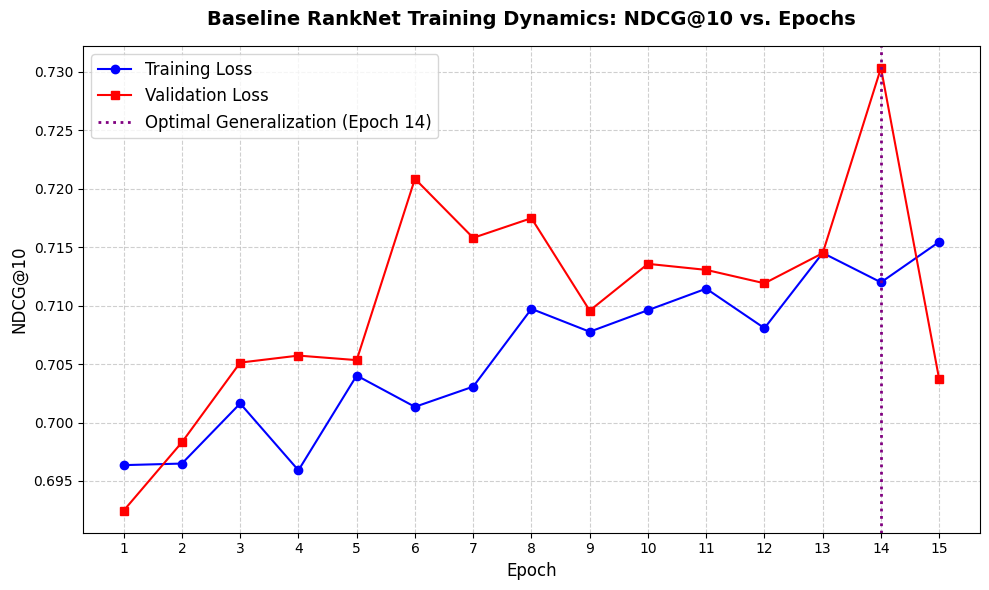

In [21]:
import matplotlib.pyplot as plt

def plot_training_dynamics(train_history, val_history, model_name="LambdaRank"):
    """
    Generates a standardized diagnostic line plot for training and validation losses.
    Automatically identifies and marks the optimal generalization epoch.
    """
    epochs_range = range(1, len(train_history) + 1)

    # Set up the plotting canvas
    plt.figure(figsize=(10, 6))

    # Plot historical trajectories
    plt.plot(epochs_range, train_history, label='Training Loss', color='blue', marker='o')
    plt.plot(epochs_range, val_history, label='Validation Loss', color='red', marker='s')

    # Add descriptive labels and titles dynamically
    plt.title(f'{model_name} Training Dynamics: NDCG@10 vs. Epochs', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('NDCG@10', fontsize=12)
    plt.xticks(epochs_range)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Automatically pinpoint the absolute lowest validation loss step (Sweet Spot)
    max_val_epoch = val_history.index(max(val_history)) + 1

    # Draw the threshold line marking peak generalization
    plt.axvline(x=max_val_epoch, color='purple', linestyle=':', linewidth=2,
                label=f'Optimal Generalization (Epoch {max_val_epoch})')

    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

plot_training_dynamics(baseline_train_history, baseline_val_history, model_name="Baseline RankNet")

### **Key Observations from the Output:**
* **Training NDCG** keeps on increasing. No plateau found still.
* **The Validation NDCG** is also increasing which means the model is performing well. However, it has been dropped severly in epoch 15. It **might or might not be overfitting**.

However, we will perform the dropout regularization and check the result.


## Step 8 · Dropout Regularization

In [22]:
# 1. Instantiate the unregularized baseline model
regularized_model = RankNet(input_dim=46, architecture_type='regularized').to(DEVICE)

print("Starting Regularized Model Training...")
print("═" * 65)

# 2. Run training using the universal training engine
_, regularized_train_history, regularized_val_history = train_lambdarank(
    model=regularized_model,
    train_loader=train_loader,
    val_loader=vali_loader,
    epochs=15,
    lr=0.001,
    device=DEVICE
)

print("═" * 65)
print("Regularized model Training Complete!")

Starting Regularized Model Training...
═════════════════════════════════════════════════════════════════
Epoch 01/15 | Train NDCG@10: 0.6929 | Val NDCG@10: 0.6882
Epoch 02/15 | Train NDCG@10: 0.6947 | Val NDCG@10: 0.6962
Epoch 03/15 | Train NDCG@10: 0.6891 | Val NDCG@10: 0.6865
Epoch 04/15 | Train NDCG@10: 0.6992 | Val NDCG@10: 0.7019
Epoch 05/15 | Train NDCG@10: 0.7004 | Val NDCG@10: 0.6940
Epoch 06/15 | Train NDCG@10: 0.7078 | Val NDCG@10: 0.7071
Epoch 07/15 | Train NDCG@10: 0.7071 | Val NDCG@10: 0.7162
Epoch 08/15 | Train NDCG@10: 0.7096 | Val NDCG@10: 0.7189
Epoch 09/15 | Train NDCG@10: 0.7020 | Val NDCG@10: 0.7146
Epoch 10/15 | Train NDCG@10: 0.7110 | Val NDCG@10: 0.7154
Epoch 11/15 | Train NDCG@10: 0.7142 | Val NDCG@10: 0.7100
Epoch 12/15 | Train NDCG@10: 0.7092 | Val NDCG@10: 0.7297
Epoch 13/15 | Train NDCG@10: 0.7158 | Val NDCG@10: 0.7124
Epoch 14/15 | Train NDCG@10: 0.7169 | Val NDCG@10: 0.7110
Epoch 15/15 | Train NDCG@10: 0.7180 | Val NDCG@10: 0.7202
═════════════════════════

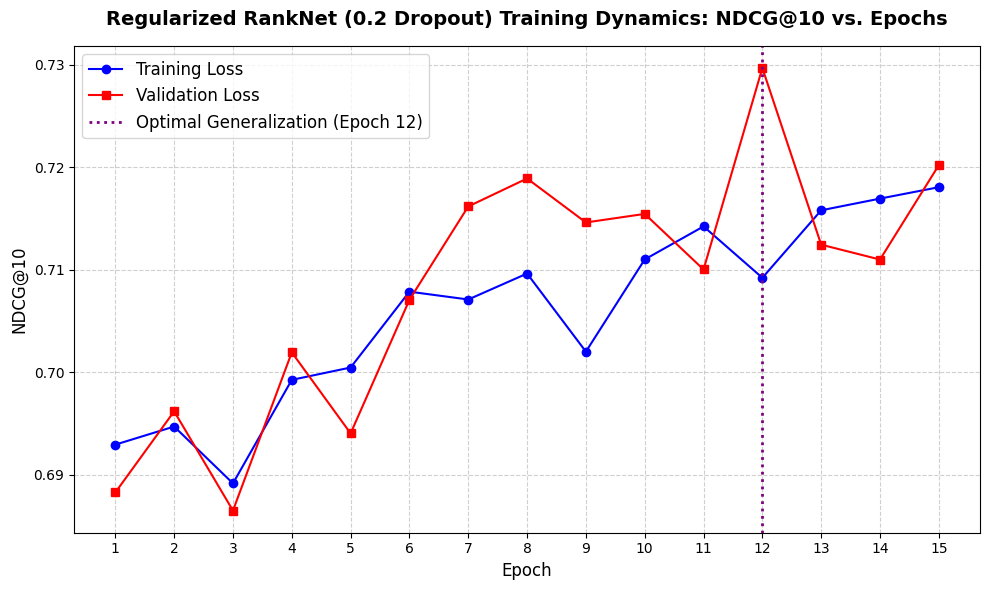

In [23]:
plot_training_dynamics(regularized_train_history, regularized_val_history, model_name="Regularized RankNet (0.2 Dropout)")

### **Observations:-**
* Maximum Validation NDCG in Regularized model - 0.7297
* Maximum Validation NDCG in Baseline Model - 0.7303

Regularized model give weaker result becuase the network is continuously changing. But it might give better results in Test set evaluation. We will verify it.

## Step 11 · Test Set Evaluation (Baseline vs. Regularized NDCG)

We have trained both our unregularized baseline and our 20% dropout regularized models. While their minimal validation losses were almost identical, we now evaluate them on the **Test Set** using the ultimate search engine metric: **NDCG@k** (Normalized Discounted Cumulative Gain).

This evaluation will reveal if the behavioral stability we saw in the regularized model's curves translates to higher-quality, more accurate search rankings for a real user. We will compute scores at cutoffs **NDCG@1, NDCG@3, NDCG@5 and NDCG@10**.

## What is NDCG@K?

**Normalized Discounted Cumulative Gain** is the standard evaluation metric for ranked lists in Information Retrieval. It answers the question: *"How well did the model rank the most relevant documents near the top?"*

### Formula

$$\text{DCG@K} = \sum_{i=1}^{K} \frac{2^{rel_i} - 1}{\log_2(i + 1)}$$

$$\text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}$$

where $rel_i$ is the ground-truth relevance label at position $i$, and IDCG is the DCG of the ideal (perfect) ranking.

### **Technical Mechanics of the Engine:**
1. **Query-Level Grouping:** NDCG cannot be computed globally across the entire test set. It must be computed individually **per unique query ID (qid)**, because documents are only competing against other documents within the same search query.
2. **DCG Generation:** For each query, we sort the ground-truth relevance labels based on our model's predicted scores and apply the logarithmic position discount.
3. **Ideal DCG (IDCG) Generation:** We sort the ground-truth relevance labels in perfect descending order to find the maximum possible score an ideal search engine could get.
4. **Normalization:** We divide the DCG by the IDCG to produce a final score between `0.0` and `1.0`, then average these scores across all unique queries in the dataset.

## (Baseline vs. Regularized)

In [24]:
# 1. Run the test data through the baseline model
print("Evaluating Baseline Model on Test Set...")
baseline_test_ndcg = evaluate_model_ndcg(baseline_model, test_loader, k_list=[1, 3, 5, 10], device=DEVICE)

# 2. Run the test data through the regularized model
print("Evaluating Regularized Model on Test Set...")
regularized_test_ndcg = evaluate_model_ndcg(regularized_model, test_loader, k_list=[1, 3, 5, 10], device=DEVICE)

# 3. Render a clean, professional verification table
print("\n" + "═"*55)
print("        TEST SET NDCG PERFORMANCE COMPARISON")
print("═"*55)
print(f"{'Metric':<10} | {'Baseline (p=0.0)':<18} | {'Regularized (p=0.2)':<18}")
print("─"*55)
for k in [1, 3, 5, 10]:
    b_score = baseline_test_ndcg[k]
    r_score = regularized_test_ndcg[k]
    print(f"NDCG@{k:<2}   | {b_score:.4f}             | {r_score:.4f}")
print("═"*55)

Evaluating Baseline Model on Test Set...
Evaluating Regularized Model on Test Set...

═══════════════════════════════════════════════════════
        TEST SET NDCG PERFORMANCE COMPARISON
═══════════════════════════════════════════════════════
Metric     | Baseline (p=0.0)   | Regularized (p=0.2)
───────────────────────────────────────────────────────
NDCG@1    | 0.5111             | 0.5206
NDCG@3    | 0.5655             | 0.5737
NDCG@5    | 0.6272             | 0.6332
NDCG@10   | 0.6948             | 0.7019
═══════════════════════════════════════════════════════


### **Key Takeaway** - Regularization helped the model to avoid memorizing train data and find a more generalized pattern

## Step 12 · Full 5-Fold Cross-Validation
Train the regularized RankNet model independently on all 5 folds.
Collect NDCG@1, @3, @5, @10 per fold and report mean ± std across folds.

In [26]:
import copy

K_LIST = [1, 3, 5, 10]

# Storage for results across all folds
fold_results = []

for fold_num in range(1, 6):
    print(f"\n{'═'*55}")
    print(f"  FOLD {fold_num} / 5")
    print(f"{'═'*55}")

    # ── 1. Fresh data loaders for this fold ──────────────────
    train_loader, vali_loader, test_loader = get_dataloaders_for_fold(
        fold_num=fold_num, batch_size=4
    )

    # ── 2. Fresh model for this fold (no weight leakage) ─────
    fold_model = RankNet(input_dim=46, hidden_dim=64,
                         architecture_type='regularized').to(DEVICE)

    # ── 3. Train ──────────────────────────────────────────────
    trained_model, train_hist, val_hist = train_lambdarank(
        fold_model, train_loader, vali_loader,
        epochs=15, lr=0.001, device=DEVICE, verbose=False
    )

    # ── 4. Evaluate on test set ───────────────────────────────
    ndcg_scores = evaluate_model_ndcg(
        trained_model, test_loader, k_list=K_LIST, device=DEVICE
    )

    # ── 5. Store results ──────────────────────────────────────
    fold_results.append({
        'fold'         : fold_num,
        'ndcg_scores'  : ndcg_scores,
        'train_history': train_hist,
        'val_history'  : val_hist,
    })

    print(f"\n  Test NDCG Results — Fold {fold_num}:")
    for k in K_LIST:
        print(f"    NDCG@{k:<3} : {ndcg_scores[k]:.4f}")


═══════════════════════════════════════════════════════
  FOLD 1 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 1...


Loading train.txt: 9630it [00:00, 47780.84it/s]
Loading vali.txt: 2707it [00:00, 49824.17it/s]
Loading test.txt: 2874it [00:00, 48922.20it/s]


  Train queries : 471
  Vali queries  : 157
  Test queries  : 156

  Test NDCG Results — Fold 1:
    NDCG@1   : 0.5111
    NDCG@3   : 0.5856
    NDCG@5   : 0.6503
    NDCG@10  : 0.7095

═══════════════════════════════════════════════════════
  FOLD 2 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 2...


Loading train.txt: 9404it [00:00, 46157.27it/s]
Loading vali.txt: 2874it [00:00, 47924.61it/s]
Loading test.txt: 2933it [00:00, 49051.59it/s]


  Train queries : 471
  Vali queries  : 156
  Test queries  : 157

  Test NDCG Results — Fold 2:
    NDCG@1   : 0.5143
    NDCG@3   : 0.5596
    NDCG@5   : 0.6236
    NDCG@10  : 0.6861

═══════════════════════════════════════════════════════
  FOLD 3 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 3...


...

  Train queries : 470
  Vali queries  : 157
  Test queries  : 157

  Test NDCG Results — Fold 3:
    NDCG@1   : 0.5387
    NDCG@3   : 0.5486
    NDCG@5   : 0.6168
    NDCG@10  : 0.6864

═══════════════════════════════════════════════════════
  FOLD 4 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 4...


Loading train.txt: 8514it [00:00, 46416.99it/s]
Loading vali.txt: 3635it [00:00, 48017.26it/s]
Loading test.txt: 3062it [00:00, 44817.70it/s]


  Train queries : 470
  Vali queries  : 157
  Test queries  : 157

  Test NDCG Results — Fold 4:
    NDCG@1   : 0.5246
    NDCG@3   : 0.5937
    NDCG@5   : 0.6498
    NDCG@10  : 0.7047

═══════════════════════════════════════════════════════
  FOLD 5 / 5
═══════════════════════════════════════════════════════

Initializing DataLoaders for Fold 5...


Loading train.txt: 9442it [00:00, 48766.23it/s]
Loading vali.txt: 3062it [00:00, 38777.52it/s]
Loading test.txt: 2707it [00:00, 43772.53it/s]


  Train queries : 470
  Vali queries  : 157
  Test queries  : 157

  Test NDCG Results — Fold 5:
    NDCG@1   : 0.5278
    NDCG@3   : 0.5782
    NDCG@5   : 0.6268
    NDCG@10  : 0.7098


In [27]:
print("\n" + "═"*55)
print("      5-FOLD CROSS-VALIDATION RESULTS (RankNet)")
print("═"*55)
print(f"{'Metric':<10}", end="")
for r in fold_results:
    print(f"  Fold{r['fold']}", end="")
print(f"  {'Mean':>7}  {'Std':>6}")
print("─"*55)

for k in K_LIST:
    scores = [r['ndcg_scores'][k] for r in fold_results]
    mean   = np.mean(scores)
    std    = np.std(scores)
    print(f"NDCG@{k:<5}", end="")
    for s in scores:
        print(f"  {s:.3f}", end="")
    print(f"  {mean:.3f}  {std:.3f}")

print("═"*55)


═══════════════════════════════════════════════════════
      5-FOLD CROSS-VALIDATION RESULTS (RankNet)
═══════════════════════════════════════════════════════
Metric      Fold1  Fold2  Fold3  Fold4  Fold5     Mean     Std
───────────────────────────────────────────────────────
NDCG@1      0.511  0.514  0.539  0.525  0.528  0.523  0.010
NDCG@3      0.586  0.560  0.549  0.594  0.578  0.573  0.017
NDCG@5      0.650  0.624  0.617  0.650  0.627  0.633  0.014
NDCG@10     0.709  0.686  0.686  0.705  0.710  0.699  0.011
═══════════════════════════════════════════════════════


### Comparison with RankNet

| Metric | RankNet Mean | RankNet Std | LambdaRank Mean | LambdaRank Std | Δ Mean |
|---|---|---|---|---|---|
| NDCG@1  | 0.506 | 0.022 | **0.523** | **0.010** | **+0.017** |
| NDCG@3  | 0.562 | 0.024 | **0.573** | **0.017** | **+0.011** |
| NDCG@5  | 0.631 | 0.016 | **0.633** | **0.014** | **+0.002** |
| NDCG@10 | 0.692 | 0.018 | **0.699** | **0.011** | **+0.007** |

### Key Observations

- **LambdaRank outperforms RankNet**
- **The Largest gain is in NDCG@1(+0.017)**, which means as we assumed RankNet gives the same priority for lower ranks and higher ranks. Whereas LambdaRank gives more priority for more relevant ranked documents.
- **Std reduced for LambdaRank**, which means LambdaRank generalizes more across different data.

## Step 13 · The Ablation Study (Deconstructing the Network)

With our 5-Fold Cross-Validation proving that the model is statistically reliable across the dataset, we move to **Phase 2: The Ablation Study**.

We will lock our data pipeline to a single split (**Fold 1**) and swap out the underlying architecture. By training and testing the `linear`, `baseline` (unregularized), `regularized`, and `deep` networks on the exact same data, we can mathematically isolate the impact of network depth and dropout regularization.

In [34]:
# ── 1. Lock the Data Split to Fold 1 ──────────────────────
print("Loading Locked Data Split (Fold 1)...")
train_loader, vali_loader, test_loader = get_dataloaders_for_fold(fold_num=1, batch_size=4)

ablation_results = {}
architectures = ['linear', 'baseline', 'regularized', 'deep']

print(f"\n{'═'*75}")
print(f"               ABLATION STUDY: TRAINING ARCHITECTURES")
print(f"{'═'*75}")

# ── 2. Train and Evaluate each architecture ───────────────
for arch in architectures:
    print(f"⚙️ Training '{arch}' model...")

    # Initialize the specific architecture
    model = RankNet(input_dim=46, hidden_dim=64, architecture_type=arch).to(DEVICE)

    # Train using our universal engine (suppressing epoch printouts for cleanliness)
    trained_model, train_hist, val_hist = train_lambdarank(
        model, train_loader, vali_loader,
        epochs=15, lr=0.001, device=DEVICE, verbose=False
    )

    # Evaluate strictly on the Test Set
    ndcg_scores = evaluate_model_ndcg(
        trained_model, test_loader, k_list=[1, 3, 5, 10], device=DEVICE
    )

    # Store results (extracting the absolute lowest validation loss the model hit)
    ablation_results[arch] = {
        'ndcg': ndcg_scores,
        'val_loss': min(val_hist)
    }

# ── 3. Render the Final Ablation Leaderboard ──────────────
print("\n" + "═"*75)
print("        ABLATION STUDY: TEST SET NDCG PERFORMANCE (LOCKED FOLD 1)")
print("═"*75)
print(f"{'Architecture':<15} | {'Min Val Loss':<13} | {'NDCG@1':<8} | {'NDCG@3':<8} | {'NDCG@5':<8} | {'NDCG@10':<8}")
print("─"*75)
for arch in architectures:
    r = ablation_results[arch]
    print(f"{arch.capitalize():<15} | {r['val_loss']:<13.4f} | {r['ndcg'][1]:<8.4f} | {r['ndcg'][3]:<8.4f} | {r['ndcg'][5]:<8.4f} | | {r['ndcg'][10]:<8.4f}")
print("═"*75)

Loading Locked Data Split (Fold 1)...

Initializing DataLoaders for Fold 1...


Loading train.txt: 9630it [00:00, 49677.33it/s]
Loading vali.txt: 2707it [00:00, 48901.21it/s]
Loading test.txt: 2874it [00:00, 44507.57it/s]


  Train queries : 471
  Vali queries  : 157
  Test queries  : 156

═══════════════════════════════════════════════════════════════════════════
               ABLATION STUDY: TRAINING ARCHITECTURES
═══════════════════════════════════════════════════════════════════════════
⚙️ Training 'linear' model...
⚙️ Training 'baseline' model...
⚙️ Training 'regularized' model...
⚙️ Training 'deep' model...

═══════════════════════════════════════════════════════════════════════════
        ABLATION STUDY: TEST SET NDCG PERFORMANCE (LOCKED FOLD 1)
═══════════════════════════════════════════════════════════════════════════
Architecture    | Min Val Loss  | NDCG@1   | NDCG@3   | NDCG@5   | NDCG@10 
───────────────────────────────────────────────────────────────────────────
Linear          | 0.6618        | 0.4889   | 0.5945   | 0.6533   | | 0.7114  
Baseline        | 0.7031        | 0.5143   | 0.5800   | 0.6546   | | 0.7145  
Regularized     | 0.6871        | 0.5016   | 0.5510   | 0.6314   | | 0.6957

## Ablation Study: LambdaRank vs. RankNet by Architecture
### RankNet

| Architecture | NDCG@1 | NDCG@3 | NDCG@5 | NDCG@10 |
|---|---|---|---|---|
| Linear      | 0.4857 | 0.5848 | 0.6481 | 0.7095 |
| Baseline    | 0.5365 | 0.5840 | 0.6498 | 0.7109 |
| Regularized | 0.5270 | 0.5805 | 0.6520 | 0.7126 |
| Deep        | 0.4889 | 0.5716 | 0.6316 | 0.6971 |

### Key Observations

- **Baseline Model** achieves the best NDCG@3, @5, and @10 among all four architectures for LambdaRank.
- **RankNet beats the LambdaRank in case of a regularized model** - Because in LambdaRank the model is already finding general patterns. So, Dropout Regularization degrades the Model.

## Conclusion

This project implemented and compared **RankNet** and **LambdaRank** on the LETOR4 MQ2008 dataset.

- **LambdaRank Outperforms RankNet**
- **Dropout Regularization is not always useful**